In [1]:
import sys

sys.path.append("qualitative_analysis_project")
from qualitative_analysis.metrics import krippendorff, gwet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path
from matplotlib.lines import Line2D
from tqdm.notebook import tqdm

# Results for all generations

In [2]:
my_dico = {}
# To read
with open("dictionnary_STUCON-tests.pkl", "rb") as f:
    my_dico = pickle.load(f)

## Generations

In [4]:
# folder, suffix = Path("VertexAI/STUCON_2.5-flash-lite_tests/"), "2.5-flash-lite"
# folder, suffix = Path("VertexAI/STUCON_2.5-flash_tests/"), "_2.5-flash"
# folder, suffix = Path("VertexAI/STUCON_2.5-pro_tests/"), "_2.5-pro"

all_models = [(Path("VertexAI/STUCON_2.5-flash-lite_tests/"), "_2.5-flash-lite"), (Path("VertexAI/STUCON_2.5-flash_tests/"), "_2.5-flash"), (Path("VertexAI/STUCON_2.5-pro_tests/"), "_2.5-pro")]
for folder, suffix in all_models:
    for file in tqdm(folder.iterdir()):
        var = file.name[:-4] + suffix
        # if not var in ("thinking_codebook_examples-with-no-reasoning_0", "thinking_codebook_examples-with-reasoning_0"):
        # if "thinking" in var:
            # continue

        df = pd.read_csv(file)
        rater_cols = [c for c in df.columns if c.startswith("Rater")]
        df["iteration"] = 1
        df["run"] = 1
        df["prompt_name"] = "streamlit_analysis"
        df["split"] = "train"
        my_dico[var] = {"df": df}

        level = "ordinal"
        domain = [1, 2, 3, 4]

        n = len(df)
        btsp = 200 if n > 3000 else 600 if n > 1000 else 1000 if n > 100 else 2000

        print("")
        print(f"*** {var} ***")
        print(f"   Level: {level}")
        print(f"   Samples: {len(df)}")

        kripp_results = krippendorff.compute_krippendorff_non_inferiority(
        detailed_results_df = df,
        annotation_columns = rater_cols,
        model_column = "rating",
        level_of_measurement = level,
        value_domain = domain,
        non_inferiority_margin = -0.05,
        n_bootstrap = btsp,
        confidence_level = 90.0,
        random_seed = 42,
        verbose = True)

        gwet_results = gwet.compute_gwet_panel_difference(
            detailed_results_df=df,
            annotation_columns=rater_cols,
            model_column="rating",
            ac_weights="quadratic",
            verbose=True,
        )

        my_dico[var]["kripp_results"] = kripp_results
        my_dico[var]["gwet_results"]  = gwet_results

0it [00:00, ?it/s]


*** codebook_0_2.5-flash-lite ***
   Level: ordinal
   Samples: 961

=== Non-inferiority Test: streamlit_analysis_iteration_1 ===
    Using 32 human annotators
    Human group: all 32 annotators
    Model groups: 32 combinations of LLM + 31 humans


Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Run 1:
    Human group (32 annotators) α: 0.8039
    Model groups (LLM + 31 humans) α: 0.2110
    Δ = model − human = -0.5930
    90% CI: [-0.6341, -0.5543]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8039 ± 0.0000
    Model substitution panel α: 0.2110 ± 0.0000
    Δ = model − human = -0.5930 ± 0.0000
    90% CI: [-0.6341, -0.5543]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 32 human annotators
    Model groups: 32 combinations of LLM + 31 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9296
    Model substitution AC: 0.5781
    Δ = model − human = -0.3515

  Summary across 1 runs:
    Human panel AC: 0.9296 ± 0.0000
    Model substitution AC: 0.5781 ± 0.0000
    Δ = model − human = -0.3515 ± 0.0000

*** codebook_1_2.5-flash-lite ***
 

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

...


  Run 1:
    Human group (32 annotators) α: 0.8039
    Model groups (LLM + 31 humans) α: 0.7160
    Δ = model − human = -0.0879
    90% CI: [-0.1143, -0.0626]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8039 ± 0.0000
    Model substitution panel α: 0.7160 ± 0.0000
    Δ = model − human = -0.0879 ± 0.0000
    90% CI: [-0.1143, -0.0626]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 32 human annotators
    Model groups: 32 combinations of LLM + 31 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9296
    Model substitution AC: 0.9008
    Δ = model − human = -0.0288

  Summary across 1 runs:
    Human panel AC: 0.9296 ± 0.0000
    Model substitution AC: 0.9008 ± 0.0000
    Δ = model − human = -0.0288 ± 0.0000

*** thinking_simplest_2.5-pro ***
 

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Run 1:
    Human group (32 annotators) α: 0.8039
    Model groups (LLM + 31 humans) α: 0.7014
    Δ = model − human = -0.1025
    90% CI: [-0.1290, -0.0766]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8039 ± 0.0000
    Model substitution panel α: 0.7014 ± 0.0000
    Δ = model − human = -0.1025 ± 0.0000
    90% CI: [-0.1290, -0.0766]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 32 human annotators
    Model groups: 32 combinations of LLM + 31 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9296
    Model substitution AC: 0.8947
    Δ = model − human = -0.0349

  Summary across 1 runs:
    Human panel AC: 0.9296 ± 0.0000
    Model substitution AC: 0.8947 ± 0.0000
    Δ = model − human = -0.0349 ± 0.0000

*** thinking_simplified_2.5-pro ***

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Run 1:
    Human group (32 annotators) α: 0.8039
    Model groups (LLM + 31 humans) α: 0.6956
    Δ = model − human = -0.1084
    90% CI: [-0.1355, -0.0804]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8039 ± 0.0000
    Model substitution panel α: 0.6956 ± 0.0000
    Δ = model − human = -0.1084 ± 0.0000
    90% CI: [-0.1355, -0.0804]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 32 human annotators
    Model groups: 32 combinations of LLM + 31 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9296
    Model substitution AC: 0.8806
    Δ = model − human = -0.0490

  Summary across 1 runs:
    Human panel AC: 0.9296 ± 0.0000
    Model substitution AC: 0.8806 ± 0.0000
    Δ = model − human = -0.0490 ± 0.0000


# Save and download the dictionnary

In [5]:
# To write
with open("dictionnary_STUCON-tests.pkl", "wb") as f:
    pickle.dump(my_dico, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# To read
with open("dictionnary_STUCON-tests.pkl", "rb") as f:
    my_dico = pickle.load(f)

# Visualizations

In [3]:
rows_kripp = []

for var, info in my_dico.items():
    results = info["kripp_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_kripp.append({
        "Variable": var,
        "Human alpha": agg["alpha_human_panel_mean"],
        "Model alpha": agg["alpha_llm_substitution_panel_mean"],
        "Difference": agg["difference_mean"],
        "CI lower": agg["ci_lower_mean"],
        "CI upper": agg["ci_upper_mean"],
        "Non-inferior runs": agg["n_non_inferior"],
        "Total runs": agg["n_runs"],
    })

kripp_df = pd.DataFrame(rows_kripp)
kripp_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs
0,codebook_2_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1
1,codebook_3_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1
2,codebook_4_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1
3,codebook_examples-with-no-reasoning_0_2.5-flas...,0.803911,0.215448,-0.588463,-0.628553,-0.547739,0,1
4,codebook_examples-with-no-reasoning_1_2.5-flas...,0.803911,0.215448,-0.588463,-0.628553,-0.547739,0,1
...,...,...,...,...,...,...,...,...
62,no-scale_2.5-pro,0.803911,0.716153,-0.087758,-0.114786,-0.062360,0,1
63,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.709012,-0.094899,-0.121555,-0.069623,0,1
64,reasoning_codebook_examples-with-reasoning_2.5...,0.803911,0.724592,-0.079319,-0.104846,-0.054555,0,1
65,simplest_2.5-pro,0.803911,0.701548,-0.102363,-0.130006,-0.074685,0,1


In [4]:
rows_ac = []

for var, info in my_dico.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac.append({
        "Variable": var,
        "Human AC": agg["ac_human_panel_mean"],
        "Model AC": agg["ac_llm_substitution_panel_mean"],
        "Delta AC": agg["difference_mean"],
    })

gwet_df = pd.DataFrame(rows_ac)
gwet_df

,Variable,Human AC,Model AC,Delta AC
0,codebook_2_2.5-flash-lite,0.92963,0.578101,-0.351529
1,codebook_3_2.5-flash-lite,0.92963,0.578101,-0.351529
2,codebook_4_2.5-flash-lite,0.92963,0.578101,-0.351529
3,codebook_examples-with-no-reasoning_0_2.5-flas...,0.92963,0.488691,-0.440939
4,codebook_examples-with-no-reasoning_1_2.5-flas...,0.92963,0.488691,-0.440939
...,...,...,...,...
62,no-scale_2.5-pro,0.92963,0.905009,-0.024621
63,reasoning_codebook_examples-with-no-reasoning_...,0.92963,0.909110,-0.020520
64,reasoning_codebook_examples-with-reasoning_2.5...,0.92963,0.921862,-0.007768
65,simplest_2.5-pro,0.92963,0.897733,-0.031897


In [5]:
model_pattern = r"(2\.5-flash-lite|2\.5-flash|2\.5-pro)"

mapping = {
    "codebook": "cbk",
    "reasoning": "rsng",
    "examples": "ex",
    "thinking": "tkg",
    "with-": ""
}

diff_df = (
    pd.DataFrame(rows_kripp)
    .sort_values("Difference")
    .assign(
        Model=lambda df: df["Variable"].str.extract(model_pattern),
        Variable_clean=lambda df: (
            df["Variable"]
            .str.replace(model_pattern, "", regex=True)
            .replace(mapping, regex=True)
            .str.strip("_- ")
        )
    )
)

diff_df["run"] = (
    diff_df["Variable_clean"]
    .str.extract(r"_(\d+)$")[0]
    .astype(float)
    .fillna(0)
    .astype(int)
    + 1
)
# Add delta AC
diff_df = diff_df.merge(
    gwet_df[["Variable", "Delta AC"]],
    on="Variable",
    how="left"
)
diff_df["Variable_clean"]=diff_df["Variable_clean"].str.replace(r"_\d+$", "", regex=True)
diff_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs,Model,Variable_clean,run,Delta AC
0,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,5,-0.439883
1,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,4,-0.439883
2,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,3,-0.439883
3,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,2,-0.439883
4,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,1,-0.439883
...,...,...,...,...,...,...,...,...,...,...,...,...
62,codebook_examples-with-no-reasoning_2.5-pro,0.803911,0.724102,-0.079809,-0.107027,-0.056154,0,1,2.5-pro,cbk_ex-no-rsng,1,-0.017971
63,reasoning_codebook_examples-with-reasoning_2.5...,0.803911,0.724592,-0.079319,-0.104846,-0.054555,0,1,2.5-pro,rsng_cbk_ex-rsng,1,-0.007768
64,thinking_codebook_2.5-pro,0.803911,0.724998,-0.078913,-0.102458,-0.055357,0,1,2.5-pro,tkg_cbk,1,-0.011709
65,codebook_2.5-pro,0.803911,0.732348,-0.071563,-0.095637,-0.048848,0,1,2.5-pro,cbk,1,-0.009403


## Stability check

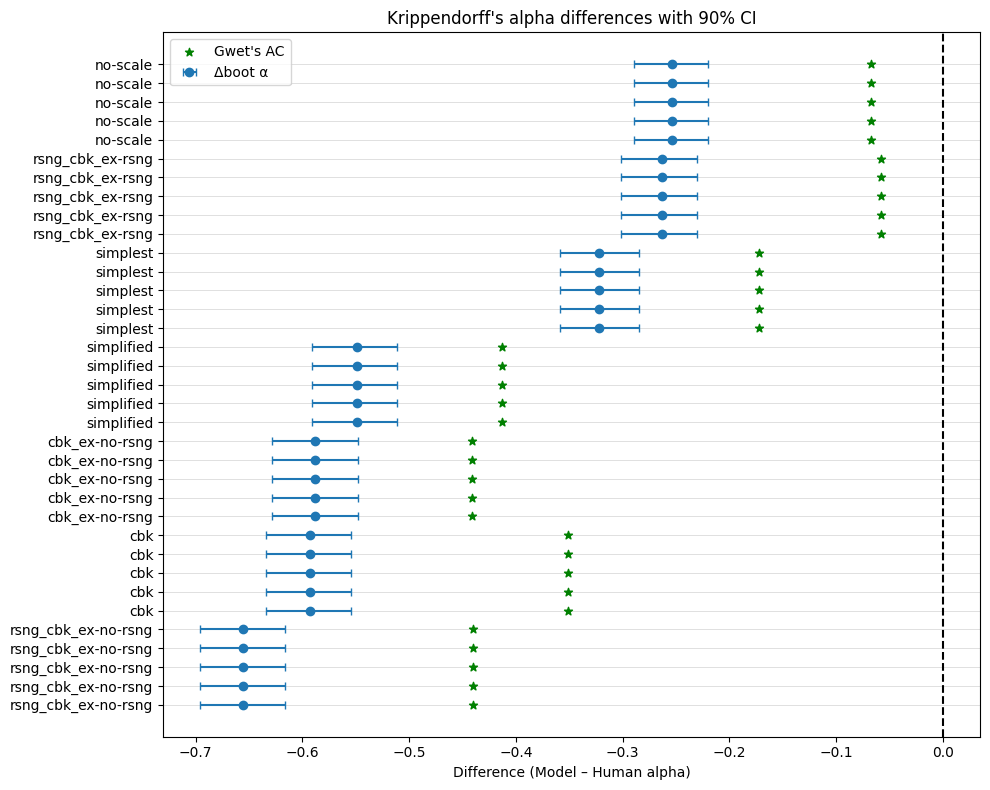

In [6]:
stab_diff_df = diff_df.loc[
    diff_df["Variable"].str.contains(r"_0_|_1_|_2_|_3_|_4_", na=False)
    & ~diff_df["Variable"].str.contains("thinking", na=False)
].copy()

y = np.arange(len(stab_diff_df))

fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(
    stab_diff_df["Difference"],
    y,
    xerr=[stab_diff_df["Difference"] - stab_diff_df["CI lower"],
          stab_diff_df["CI upper"] - stab_diff_df["Difference"]],
    fmt="o",
    capsize=3,
    label="Δboot α"
)
x_ac = stab_diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
    label="Gwet's AC"
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)

ax.set_yticklabels(stab_diff_df["Variable_clean"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

plt.legend()
plt.tight_layout()
#plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
stab_diff_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs,Model,Variable_clean,run,Delta AC
0,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,5,-0.439883
1,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,4,-0.439883
2,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,3,-0.439883
3,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,2,-0.439883
4,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,-0.695808,-0.616558,0,1,2.5-flash-lite,rsng_cbk_ex-no-rsng,1,-0.439883
5,codebook_2_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1,2.5-flash-lite,cbk,3,-0.351529
6,codebook_1_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1,2.5-flash-lite,cbk,2,-0.351529
7,codebook_0_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1,2.5-flash-lite,cbk,1,-0.351529
8,codebook_4_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1,2.5-flash-lite,cbk,5,-0.351529
9,codebook_3_2.5-flash-lite,0.803911,0.210961,-0.592950,-0.634102,-0.554326,0,1,2.5-flash-lite,cbk,4,-0.351529


In [8]:
summary_stab = (
    stab_diff_df
    .groupby("Variable_clean")["Difference"]
    .agg(
        Mean_delta_alpha="mean",
        SD="std",
        Range=lambda x: x.max() - x.min()
    )
    .sort_values("Mean_delta_alpha")
    .reset_index()
)

summary_stab.round(3)

,Variable_clean,Mean_delta_alpha,SD,Range
0,rsng_cbk_ex-no-rsng,-0.656,0.0,0.0
1,cbk,-0.593,0.0,0.0
2,cbk_ex-no-rsng,-0.588,0.0,0.0
3,simplified,-0.549,0.0,0.0
4,simplest,-0.322,0.0,0.0
5,rsng_cbk_ex-rsng,-0.263,0.0,0.0
6,no-scale,-0.254,0.0,0.0


## Forestplot

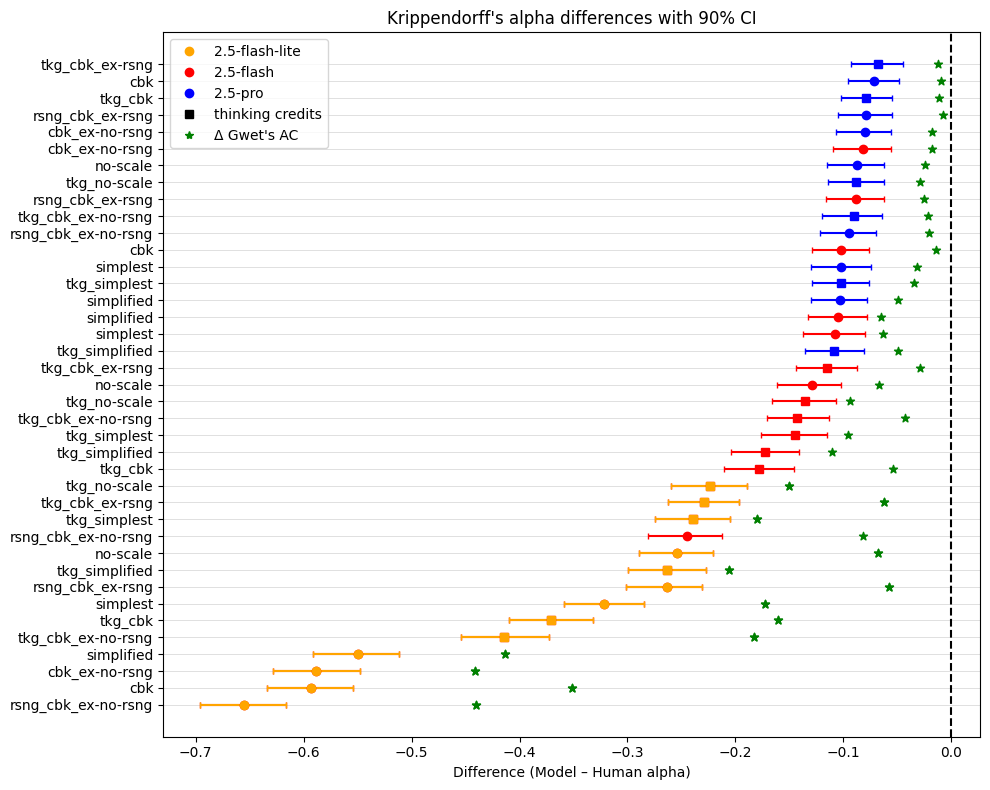

In [9]:
mask_keep = ~diff_df["Variable"].str.contains(r"_1_|_2_|_3_|_4_", na=False)
subset_diff_df = diff_df.loc[mask_keep].copy()

y = np.arange(len(subset_diff_df))

fig, ax = plt.subplots(figsize=(10, 8))

mask1 = subset_diff_df["Variable"].str.contains("2.5-flash")
mask2 = subset_diff_df["Variable"].str.contains("2.5-flash-lite")
mask3 = subset_diff_df["Variable"].str.contains("2.5-pro")

groups = [
    (mask1, "2.5-flash", "red"),
    (mask2, "2.5-flash-lite", "orange"),
    (mask3, "2.5-pro", "blue"),
]

for mask, label, color in groups:
    subset = subset_diff_df.loc[mask]
    y_subset = y[mask]

    # Conditional markers for "thinking" variables
    markers = subset["Variable"].str.contains("thinking", case=False, na=False)

    # Krippendorff
    for xi, yi, diff, ci_low, ci_up, is_thinking in zip(
        subset["Difference"],
        y_subset,
        subset["Difference"],
        subset["CI lower"],
        subset["CI upper"],
        markers
    ):
        ax.errorbar(
            xi,
            yi,
            xerr=[[diff - ci_low], [ci_up - diff]],
            fmt='s' if is_thinking else 'o',
            color=color,
            capsize=2.5,
        )
    
    x_ac = subset["Delta AC"].astype(float).to_numpy()
    y_ac = y_subset
    ax.scatter(
        x_ac,
        y_ac,
        marker="*",
        color="green",
    )
    

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )

ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(subset_diff_df["Variable_clean"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

legend_elements = [
    Line2D([0], [0], marker='o', color='orange', linestyle='None', label='2.5-flash-lite'),
    Line2D([0], [0], marker='o', color='red', linestyle='None', label='2.5-flash'),
    Line2D([0], [0], marker='o', color='blue', linestyle='None', label='2.5-pro'),
    Line2D([0], [0], marker='s', color='black', linestyle='None', label='thinking credits'),
    Line2D([0], [0], marker='*', color='green', linestyle='None', label='Δ Gwet\'s AC'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
#plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Distributions

In [10]:
order = [# THINKING EXAMPLES REASONING
         'thinking_codebook_examples-with-reasoning_0_2.5-flash-lite',
         'thinking_codebook_examples-with-reasoning_2.5-flash',
         'thinking_codebook_examples-with-reasoning_2.5-pro',

        # REASONING EXAMPLES REASONING
         'reasoning_codebook_examples-with-reasoning_0_2.5-flash-lite',
         'reasoning_codebook_examples-with-reasoning_2.5-flash',
         'reasoning_codebook_examples-with-reasoning_2.5-pro',
         
         # THINKING EXAMPLES no-REASONING
         'thinking_codebook_examples-with-no-reasoning_0_2.5-flash-lite',
         'thinking_codebook_examples-with-no-reasoning_2.5-flash',
         'thinking_codebook_examples-with-no-reasoning_2.5-pro',

         # REASONING EXAMPLES no-REASONING
         'reasoning_codebook_examples-with-no-reasoning_0_2.5-flash-lite',
         'reasoning_codebook_examples-with-no-reasoning_2.5-flash',
         'reasoning_codebook_examples-with-no-reasoning_2.5-pro',

         # EXAMPLES no-REASONING
         'codebook_examples-with-no-reasoning_0_2.5-flash-lite',
         'codebook_examples-with-no-reasoning_2.5-flash',
         'codebook_examples-with-no-reasoning_2.5-pro',
          
          # THINKING CODEBOOK
         'thinking_codebook_0_2.5-flash-lite',
         'thinking_codebook_2.5-flash',
         'thinking_codebook_2.5-pro',

         # CODEBOOK
         'codebook_0_2.5-flash-lite',
         'codebook_2.5-flash',
         'codebook_2.5-pro',

         # THINKING SIMPLIFIED
         'thinking_simplified_0_2.5-flash-lite',
         'thinking_simplified_2.5-flash',
         'thinking_simplified_2.5-pro',

         # SIMPLIFIED
         'simplified_0_2.5-flash-lite',
         'simplified_2.5-flash',
         'simplified_2.5-pro',
         
         # THINKING SIMPLEST
         'thinking_simplest_0_2.5-flash-lite',
         'thinking_simplest_2.5-flash',
         'thinking_simplest_2.5-pro',

         # SIMPLEST
         'simplest_0_2.5-flash-lite',
         'simplest_2.5-flash',
         'simplest_2.5-pro',

         # THINKING no-SCALE
         'thinking_no-scale_0_2.5-flash-lite',
         'thinking_no-scale_2.5-flash',
         'thinking_no-scale_2.5-pro',

         # no-SCALE
         'no-scale_0_2.5-flash-lite',
         'no-scale_2.5-flash', 
         'no-scale_2.5-pro',
        ]

to_remove = ['reasoning_codebook_examples-with-reasoning_2.5-pro', 'reasoning_codebook_examples-with-no-reasoning_2.5-pro',
             'codebook_examples-with-no-reasoning_2.5-pro', 'codebook_2.5-pro', 'simplified_2.5-pro', 'simplest_2.5-pro',
             'no-scale_2.5-pro']

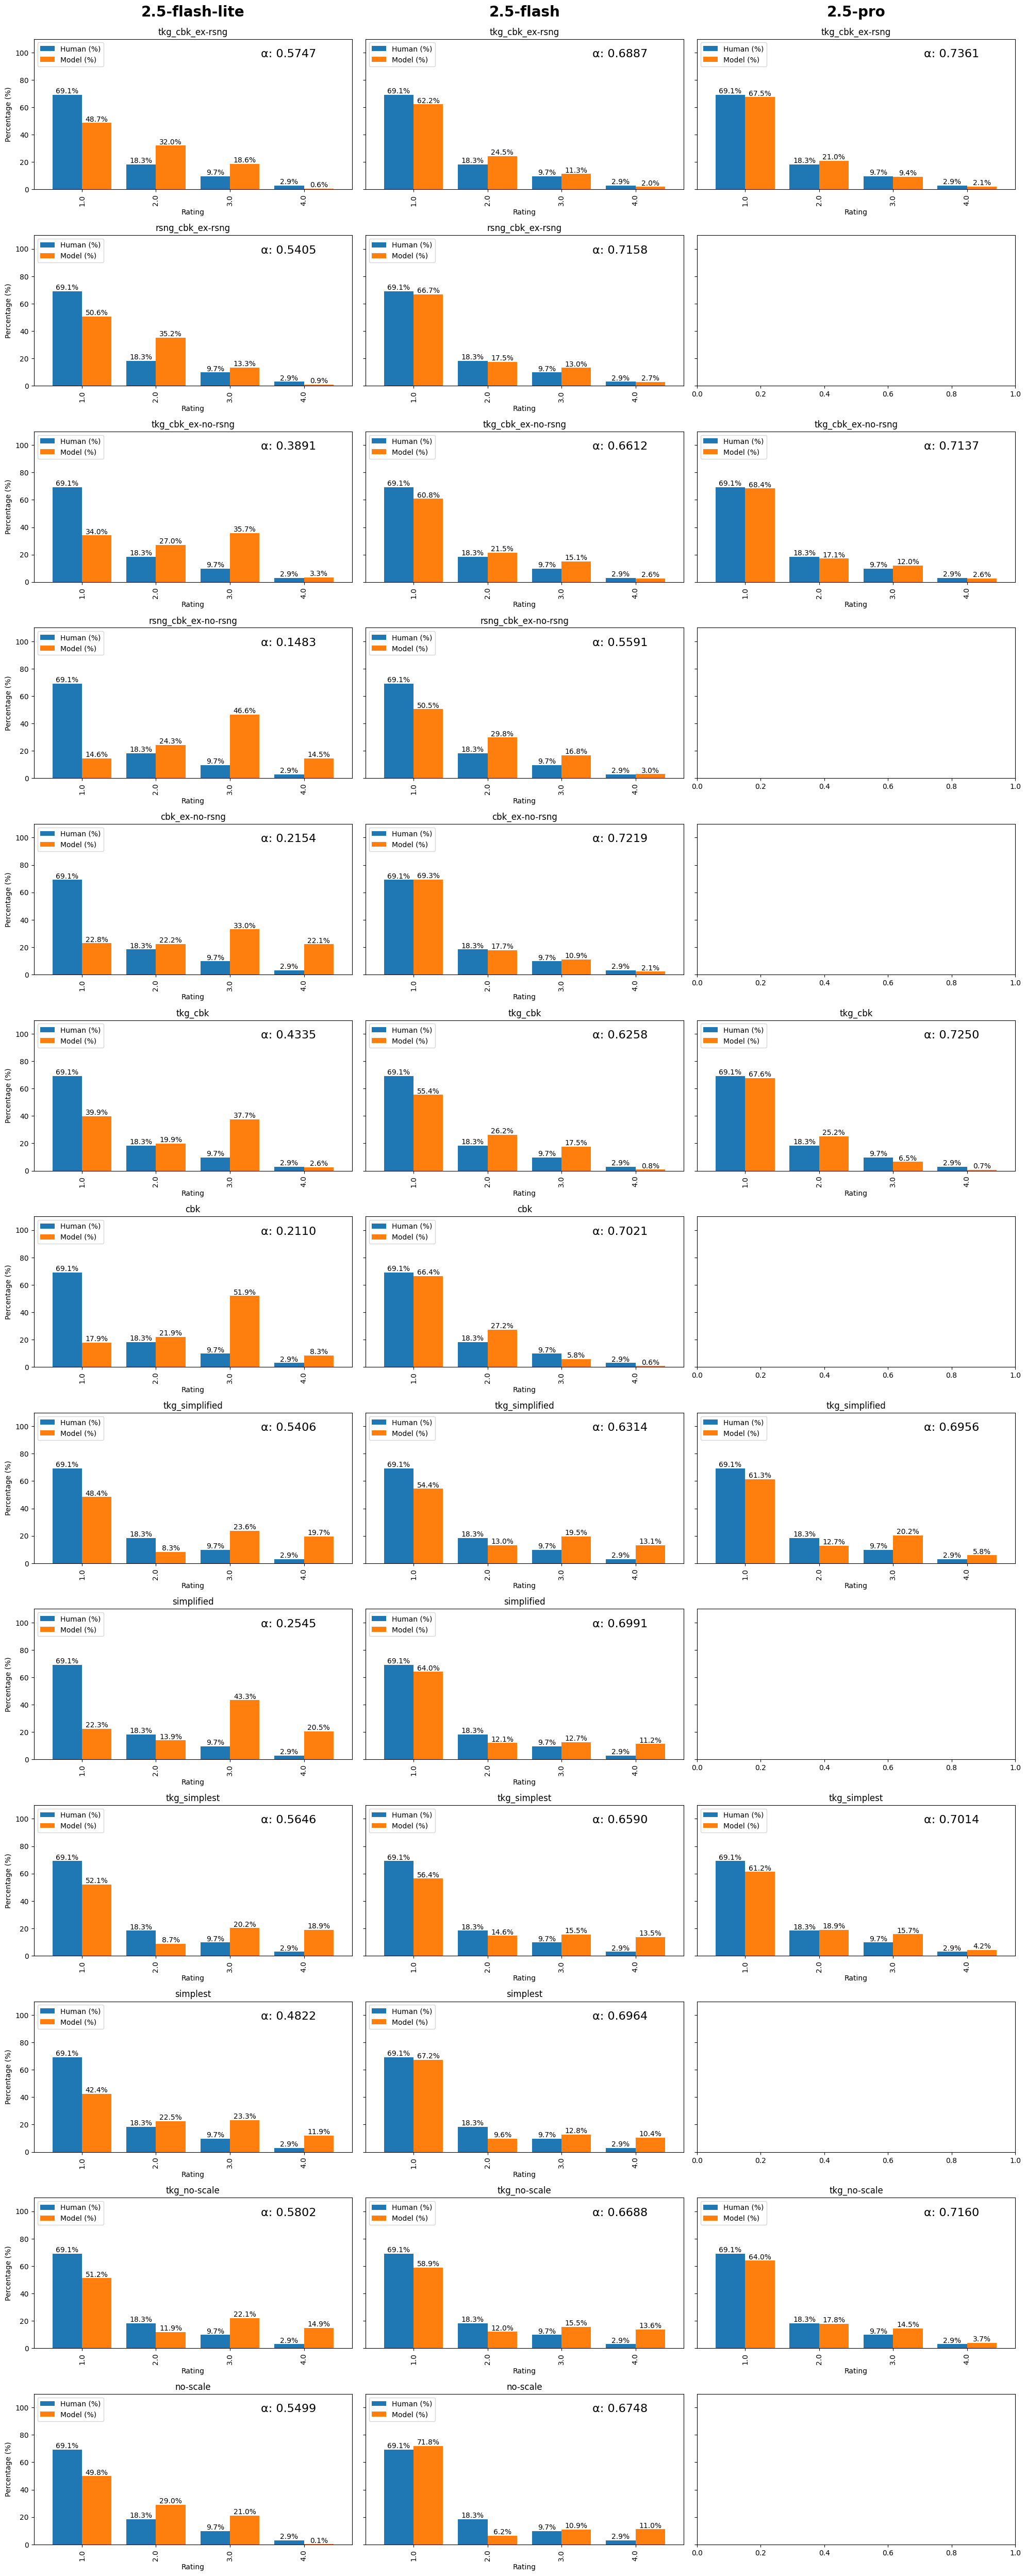

In [11]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(20, 50), sharey=True)#, sharex=True)
axes_flat = axes.flatten()

for (var, ax) in zip(order, axes_flat):
    if var in to_remove:
        continue
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    humans = df[rater_cols].stack().dropna()
    model = df["rating"]

    counts_h = humans.value_counts(normalize=True).sort_index() * 100
    counts_m = model.value_counts(normalize=True).sort_index() * 100

    idx = sorted(set(counts_h.index) | set(counts_m.index))
    plot_df = pd.DataFrame({
        "Human (%)": counts_h,
        "Model (%)": counts_m
    })

    plot_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(subset_diff_df.loc[subset_diff_df["Variable"] == var, "Variable_clean"].iloc[0])
    ax.set_xlabel("Rating")
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim([0, 110])

    # Display percent values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")

    value = kripp_df.set_index("Variable").loc[var, "Model alpha"]
    ax.text(
        0.8,
        0.9,
        f"α: {value:.4f}",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=16
    )

col_titles = ["2.5-flash-lite", "2.5-flash", "2.5-pro"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(
        title,
        xy=(0.5, 1.15),
        xycoords="axes fraction",
        ha="center",
        fontsize=20,
        weight="bold"
    )

plt.tight_layout()
# plt.savefig("kripp_diff_barplots.png", dpi=300, bbox_inches="tight")
plt.show()

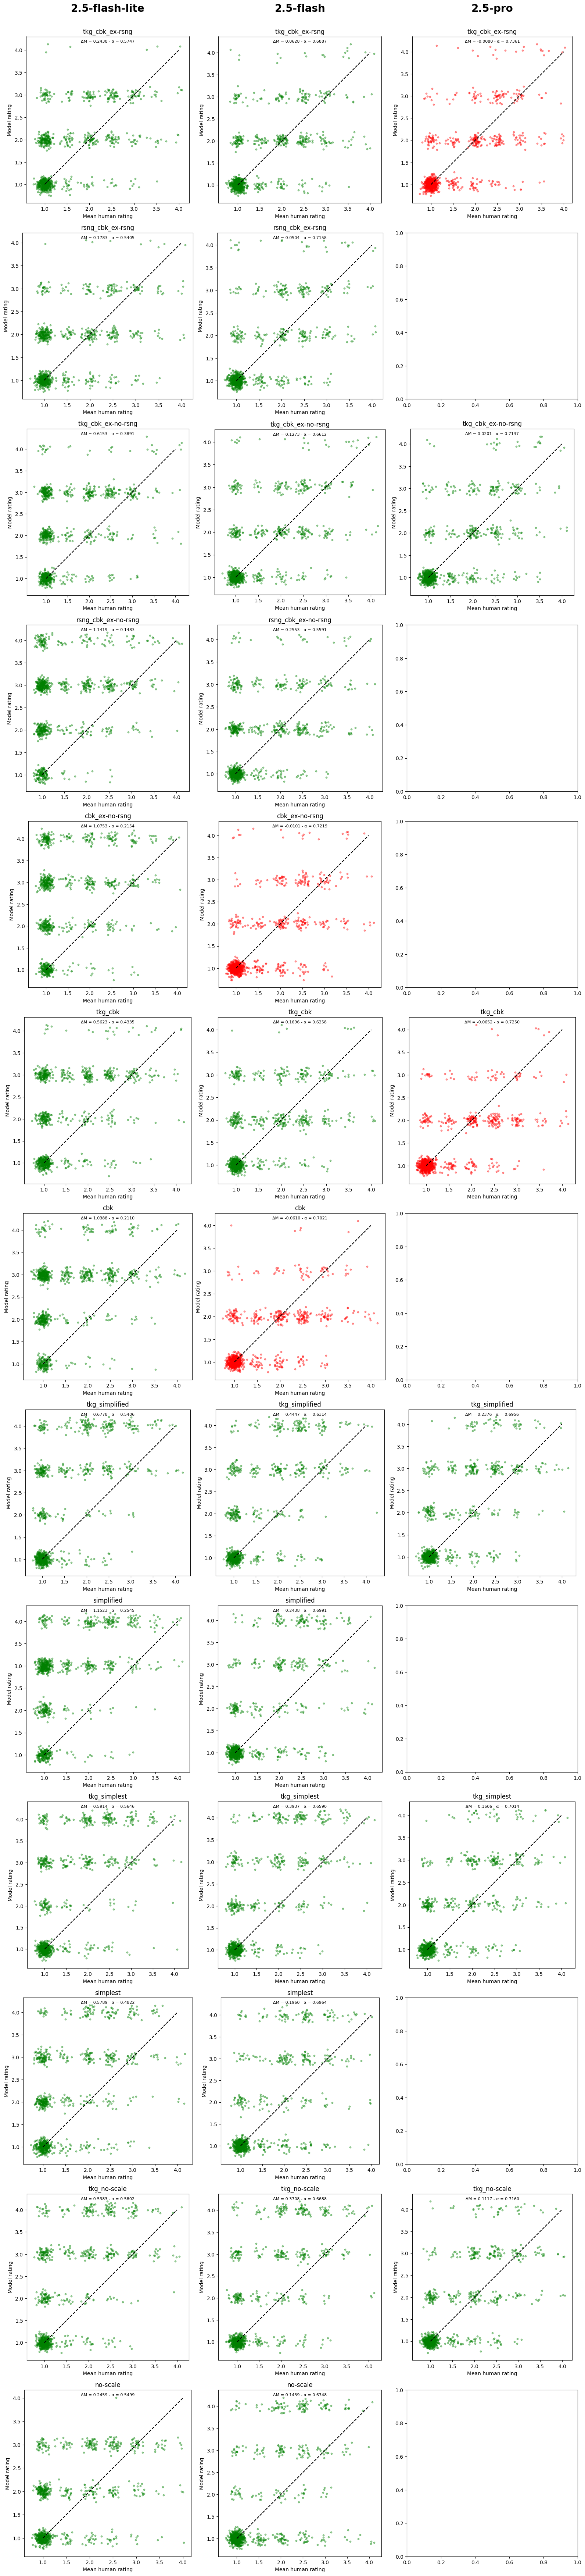

In [12]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(16, 70))

axes_flat = axes.flatten()

for var, ax in zip(order, axes_flat):
    if var in to_remove:
        continue
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    # Human mean per item
    human_mean = df[rater_cols].mean(axis=1, skipna=True)
    model = df["rating"]
    diff_mean = (model - human_mean).mean()
    colors = "green" if diff_mean > 0 else "red"
         
    # Jitter
    jitter_x = np.random.normal(0, 0.08, size=len(human_mean))
    jitter_y = np.random.normal(0, 0.08, size=len(model))

    # Scatter
    ax.scatter(
        human_mean + jitter_x,
        model + jitter_y,
        c=colors,
        alpha=0.4,
        s=10
    )

    # Diagonale y = x
    min_val = min(human_mean.min(), model.min())
    max_val = max(human_mean.max(), model.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

    # Title
    ax.set_title(subset_diff_df.loc[subset_diff_df["Variable"] == var, "Variable_clean"].iloc[0])
    # Subtitle with ΔM and α
    kripp_val = kripp_df.set_index("Variable").loc[var, "Model alpha"]
    ax.text(0.5, 0.97, f"ΔM = {diff_mean:.4f} - α = {kripp_val:.4f}", ha="center", va="center", transform=ax.transAxes, fontsize=8)

    ax.set_xlabel("Mean human rating")
    ax.set_ylabel("Model rating")
    ax.set_aspect("equal", "box")

col_titles = ["2.5-flash-lite", "2.5-flash", "2.5-pro"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(
        title,
        xy=(0.5, 1.15),
        xycoords="axes fraction",
        ha="center",
        fontsize=20,
        weight="bold"
    )
    
plt.tight_layout()
plt.show()